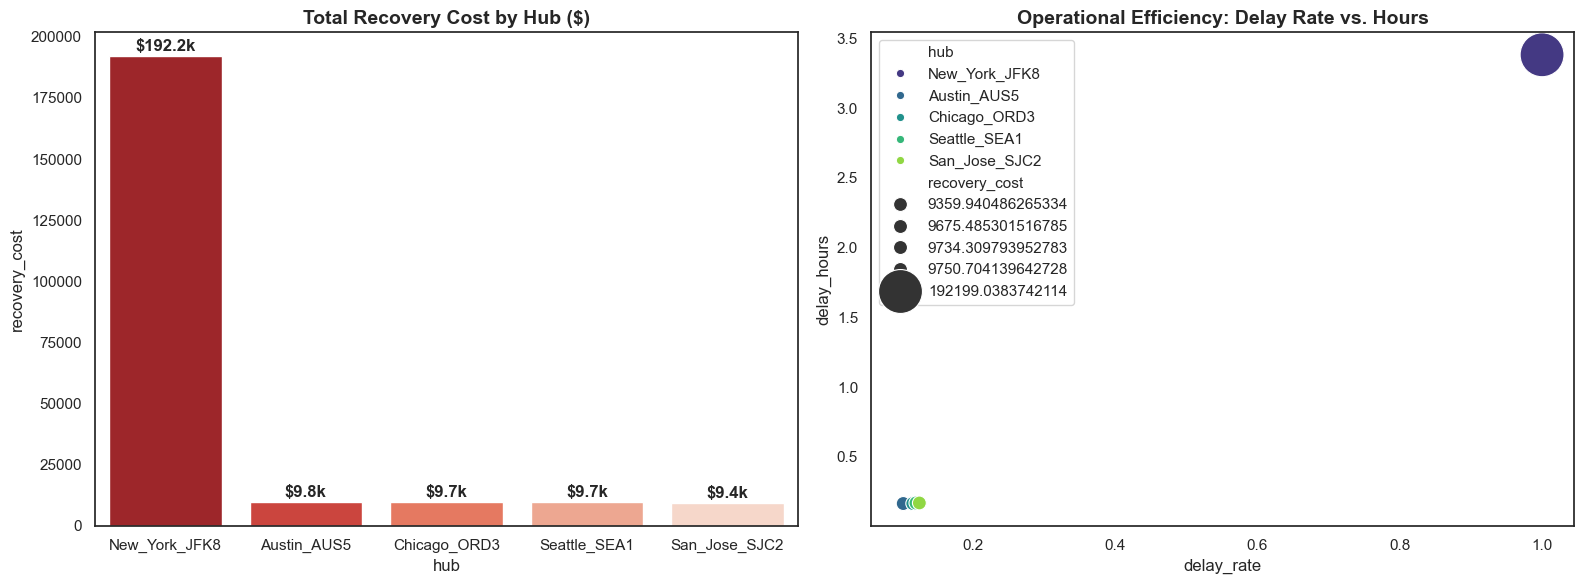

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setting up Environment
np.random.seed(44)
for folder in ['data', 'visuals']:
    if not os.path.exists(folder): os.makedirs(folder)

# 2. Data Generation 
n_orders = 15000
hubs = ['Seattle_SEA1', 'San_Jose_SJC2', 'Austin_AUS5', 'New_York_JFK8', 'Chicago_ORD3']

data = pd.DataFrame({
    'order_id': range(1001, 1001 + n_orders),
    'hub': np.random.choice(hubs, size=n_orders),
    'distance_miles': np.random.uniform(5, 50, size=n_orders),
    'priority': np.random.choice(['Standard', 'Express', 'Same-Day'], size=n_orders, p=[0.6, 0.3, 0.1])
})

# Simulating delivery hours & Bottleneck in JFK8
data['planned_hours'] = 4 + (data['distance_miles'] * 0.1)
data['actual_hours'] = data['planned_hours'] * np.where(
    data['hub'] == 'New_York_JFK8',
    np.random.uniform(1.2, 1.8, n_orders), # The Bottleneck
    np.random.uniform(0.9, 1.1, n_orders)
)

data['delay_hours'] = (data['actual_hours'] - data['planned_hours']).clip(lower=0)
data['is_delayed'] = data['delay_hours'] > 0.5

# 3. Cost Logic 
data['recovery_cost'] = np.where(
    data['priority'] == 'Standard',
    data['delay_hours'] * 15,
    data['delay_hours'] * 25
)

# 4. EXPORTING DATA
data.to_csv('data/logistics_delivery_data.csv', index=False)

# 5. Visualizing Financial Impact 
hub_analysis = data.groupby('hub').agg({
    'is_delayed': 'mean',
    'delay_hours': 'mean',
    'recovery_cost': 'sum'
}).rename(columns={'is_delayed': 'delay_rate'}).sort_values('recovery_cost', ascending=False)

sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart
sns.barplot(ax=axes[0], x=hub_analysis.index, y='recovery_cost', data=hub_analysis, palette='Reds_r', hue=hub_analysis.index, legend=False)
axes[0].set_title('Total Recovery Cost by Hub ($)', fontsize=14, fontweight='bold')
for i, v in enumerate(hub_analysis['recovery_cost']):
    axes[0].text(i, v + 2000, f'${v/1000:.1f}k', ha='center', fontweight='bold')

# Plot 2: Scatter Plot
sns.scatterplot(ax=axes[1], x='delay_rate', y='delay_hours', size='recovery_cost', hue=hub_analysis.index, data=hub_analysis, sizes=(100, 1000), palette='viridis')
axes[1].set_title('Operational Efficiency: Delay Rate vs. Hours', fontsize=14, fontweight='bold')

plt.tight_layout()
# SAVING VISUAL
plt.savefig('visuals/hub_cost_efficiency_matrix.png', dpi=300)
plt.show()